<div style="text-align: center;">

# Deep Convolutional Generative Adversarial Networks (DCGAN)

</div>

**Author**: Dr. Amir Omidvarnia  
**Email**: a.omidvarnia@fz-juelich.de  
**Affiliation**: Forschungszentrum Jülich, Germany  
**Event**: DPG2026 AKPIK tutorial on ML-based image processing for electrochemical applications (7 March 2026)

---

## Overview

**Generative Adversarial Networks (GANs)** learn to synthesize new images by training two neural networks in competition: a *generator* that maps random latent vectors to candidate images, and a *discriminator* that tries to distinguish real images from generated ones. This adversarial game pushes the generator toward producing images that are statistically indistinguishable from the training distribution.

The **DCGAN** variant replaces fully connected layers with convolutional and transposed-convolutional layers, making it well-suited for learning the spatial statistics of microscopy images. Once trained on real SEM frames, the generator can produce an unlimited number of novel synthetic images — each with a corresponding segmentation mask derived from the generation process — for use in downstream segmentation model training.

### How synthetic labels are produced

Because the DCGAN generates images from a latent code, binary masks are derived from the generated pixel intensities rather than from manual annotation. This makes GAN-based augmentation scalable but means that mask quality depends on the fidelity of the generative model.

### Workflow

1. Load configuration (architecture hyperparameters, dataset paths, latent dimension).
2. Prepare training data and initialize the DCGAN generator and discriminator.
3. Train adversarially: alternate updates of discriminator and generator until convergence.
4. Sample synthetic images from the trained generator and inspect them against real training images.
5. Analyze training dynamics (loss curves, discriminator accuracy) to assess GAN stability.

### DCGAN Experiment Setup

This notebook configures a deep convolutional generative adversarial network (DCGAN) to learn the empirical distribution of electron microscopy images and to synthesize new samples from a low-dimensional latent space, providing a controlled framework for studying how data-driven generative models can augment electrochemical imaging datasets.


In [1]:
# Import necessary modules
from pathlib import Path
import sys
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import logging

# !!!!!!!!!!!!!!!!!!!!!! Be careful with the force flag !!!!!!!!!!!!!!!!!!!!!!
force=True  # Force re-preparation of directories and models
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

# Define method name and number of images for training
method_name = 'DCGAN'
N_images = 73  # Number of training images to use for synthesis
dataset = 'dataset_lithiation_256'

# Set the path to include the repository root
try:
    notebook_dir = Path(__file__).resolve().parent
except Exception:
    notebook_dir = Path.cwd()

cur = notebook_dir
repo_root = None
for _ in range(6):
    if (cur / 'src').exists():
        repo_root = cur
        break
    if cur.parent == cur:
        break
    cur = cur.parent

if repo_root is None:
    repo_root = Path.cwd()

modules_dir = repo_root / 'src'
repo_root_str = str(repo_root)
if repo_root_str not in sys.path:
    sys.path.insert(0, repo_root_str)
print(f'Added repo root to sys.path: {repo_root_str} (src dir: {modules_dir})')

from src.synth_data_module import SynthDataGenerator
from src.synth_data_module import ConfigLoader
from src.synth_data_module import PreparationManager

Added repo root to sys.path: /Users/amir/GIT_repositories/juspice_release (modules dir: /Users/amir/GIT_repositories/juspice_release/modules)


/Users/amir/GIT_repositories/juspice_release/.dpg2026/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Imports and Experiment Parameters

Cell 1 performs two roles simultaneously: it (1) imports all necessary Python libraries (PyTorch, PIL, NumPy, Matplotlib, logging) and JUSPICE preparation and synthesis modules, and (2) sets the key experimental parameters — the synthesis method name (`DCGAN`), the number of real training images (`N_images`), the target dataset (`dataset_lithiation_256`), and a `force` flag that controls whether previously generated models and directories are overwritten. The repository root is also located dynamically here.

By fixing these parameters at the top of the notebook, the experiment is self-documenting: any collaborator running this cell can immediately see what data, how many images, and which method are being studied.


In [2]:
# Logging configuration
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

# Set device for PyTorch
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
    
logging.info(f"Using device: {device}.")


25:02:2026 23:57:17 - Using device: mps.


### Computational Backend and Logging
Here we select the numerical backend (CPU, GPU, or Apple Silicon accelerators) and configure logging, which determines both the computational capacity available to the DCGAN and the level of traceability of its training dynamics.
From a methodological perspective, this step fixes the hardware-dependent aspects of the experiment, enabling fair comparison of model behaviour across repeated runs and different augmentation strategies.

In [ ]:
# Load configuration from YAML file
config_path = repo_root / 'tutorial_parameters.yaml'
config = ConfigLoader(config_path)
logging.info(f"Configuration loaded from: {config_path}")

25:02:2026 23:57:17 - Configuration loaded from: /Users/amir/GIT_repositories/juspice_release/dpg2026_tutorial_parameters_mac.yaml


### Hyperparameter Configuration
This block loads the YAML configuration that encodes the structural and training hyperparameters of the DCGAN, such as latent dimensionality, filter widths, learning rates, and batch sizes.
Treating these values as part of an explicit experimental design allows systematic exploration of how network capacity and optimisation settings influence the fidelity and diversity of the synthesized electrochemical images.

In [4]:
# Ensure required top-level config keys exist (provide sensible defaults if missing)
cfg_dict = getattr(config, 'config', None)
if cfg_dict is None:
    raise RuntimeError('ConfigLoader did not load a configuration dictionary.')

if 'synth_models_dir' not in cfg_dict:
    cfg_dict['synth_models_dir'] = os.path.join(cfg_dict.get('models_dir', os.getcwd()), 'synth_models')
if 'segmentation_models_dir' not in cfg_dict:
    cfg_dict['segmentation_models_dir'] = os.path.join(cfg_dict.get('models_dir', os.getcwd()), 'segmentation_models')
    
# Re-wrap config back into ConfigLoader if necessary (ConfigLoader keeps reference to cfg_dict)
prep_manager_dcgan = PreparationManager(
    config=config, 
    input_dataset=dataset, 
    method_name=method_name, 
    analysis_level='synth_generation'
)

# Initialize SynthDataGenerator
generator = SynthDataGenerator(
    prep_manager=prep_manager_dcgan,
    config=config,
    method_name=method_name,
    N_images=N_images,
    device=device
)

print(f"Generator initialized with {N_images} training images")
print(f"Using device: {device}")
print(f"\nNote: DCGAN training may take several minutes...")

Generator initialized with 73 training images
Using device: mps

Note: DCGAN training may take several minutes...


### Data Pipeline and Generator Initialization
In this step, configuration settings are bound to concrete data paths and model checkpoints, and a DCGAN-based synthesis pipeline is instantiated for a specified number of training images.
Conceptually, this couples the empirical distribution of the selected electron microscopy dataset to a parametric generative model, defining how real microstructural variability is projected into the model’s latent space.

In [5]:
# Train DCGAN and generate synthetic images
print("Starting DCGAN training and generation...")
generator.generate()
print("\nTraining and generation complete!")

25:02:2026 23:57:17 - Parameters for the DCGAN model were set.
25:02:2026 23:57:17 - Initial parameters and file/folder paths were set.
25:02:2026 23:57:17 - Preprocessing training images...


Starting DCGAN training and generation...


Preprocessing images: 100%|██████████| 73/73 [00:00<00:00, 413.16it/s]
25:02:2026 23:57:17 - Training images and masks were preprocessed.
25:02:2026 23:57:17 - Test images and masks were preprocessed.
25:02:2026 23:57:17 - *******************


Preprocessing complete.
Images saved to: /Users/amir/Documents/JuSPICE_Tutorial/preprocessed_data/DCGAN_dataset_lithiation_256/input_images
Masks saved to: /Users/amir/Documents/JuSPICE_Tutorial/preprocessed_data/DCGAN_dataset_lithiation_256/input_masks


/Users/amir/GIT_repositories/juspice_release/.dpg2026/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/amir/GIT_repositories/juspice_release/.dpg2026/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


...


Checkpoint saved at epoch 100
Loading generator from checkpoint: /Users/amir/Documents/JuSPICE_Tutorial/Models/synth_models/DCGAN_dataset_lithiation_256/ckpt-1


Generating synthetic images: 100%|██████████| 5/5 [00:00<00:00, 376.41it/s]
26:02:2026 00:06:41 - Synthetic data generation completed.



Saved 5 synthetic images to /Users/amir/Documents/JuSPICE_Tutorial/Synthetic_images/DCGAN_dataset_lithiation_256/images
Saved 5 masks to /Users/amir/Documents/JuSPICE_Tutorial/Synthetic_images/DCGAN_dataset_lithiation_256/masks


Generating augmented images: 100%|██████████| 5/5 [01:09<00:00, 13.95s/it]
26:02:2026 00:07:51 - Synthetic image and masks were generated and saved.



Training and generation complete!


### Adversarial Training and Synthetic Sampling
Here the DCGAN is trained adversarially: the generator learns to map latent vectors to candidate images while the discriminator learns to distinguish real from synthetic microstructures, and both networks iterate toward a Nash-like equilibrium.
Once trained, the generator is used to sample new electron microscopy-like images, effectively drawing from an implicit model of the data distribution for downstream augmentation studies.

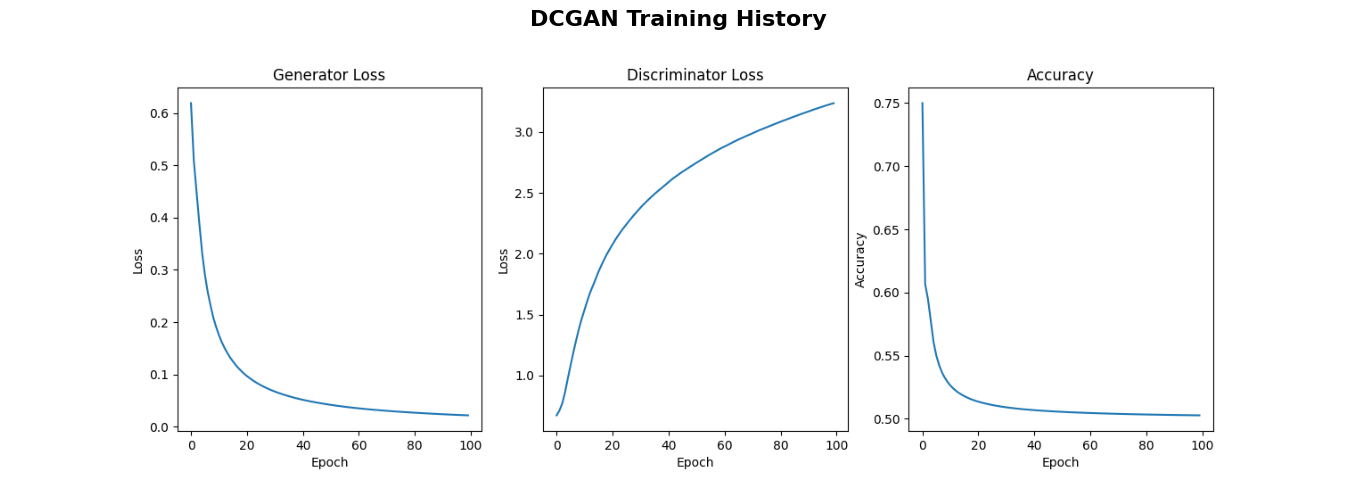

Training history displayed successfully!


In [6]:
# Load training history plot
synth_images_dir = os.path.dirname(prep_manager_dcgan.output_images_dir)
history_plot_path = os.path.join(synth_images_dir, 'training_history.png')

if os.path.exists(history_plot_path):
    history_img = Image.open(history_plot_path)
    
    plt.figure(figsize=(15, 5))
    plt.imshow(history_img)
    plt.axis('off')
    plt.title('DCGAN Training History', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Training history displayed successfully!")
else:
    print(f"Training history plot not found at: {history_plot_path}")

### Training Dynamics Visualization
This cell visualizes stored training curves, such as generator and discriminator losses and discriminator accuracy, summarised into a single history image.
From a modelling standpoint, these curves reveal whether the adversarial game is stable, collapsing, or oscillatory, and thus whether the learned synthetic distribution is likely to be faithful to the underlying electrochemical image statistics.

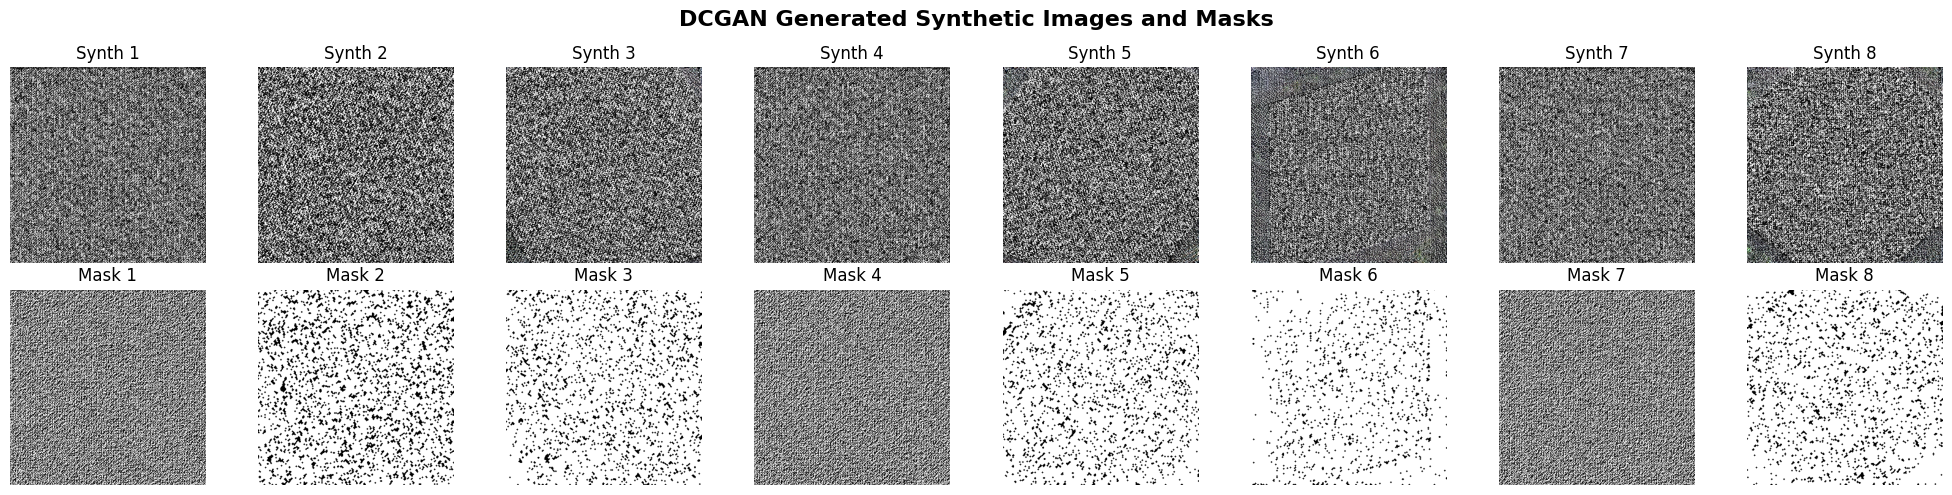


Displayed 8 synthetic images
Total images generated: 15


In [7]:
# Get paths to output directories
output_images_dir = prep_manager_dcgan.output_images_dir
output_masks_dir = prep_manager_dcgan.output_bin_masks_dir

# Load generated images
image_files = sorted([f for f in os.listdir(output_images_dir) if f.endswith(('.png', '.jpg'))])[:8]

# Create visualization
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle('DCGAN Generated Synthetic Images and Masks', fontsize=16, fontweight='bold')

for idx, img_file in enumerate(image_files):
    # Load image and mask
    image_ext = os.path.splitext(img_file)[1]
    image_name = os.path.splitext(img_file)[0]
    img_path = os.path.join(output_images_dir, img_file)
    mask_path = os.path.join(output_masks_dir, f"{image_name}.png")
    
    img = Image.open(img_path)
    mask = Image.open(mask_path)
    
    # Display image
    axes[0, idx].imshow(img, cmap='gray')
    axes[0, idx].set_title(f'Synth {idx+1}')
    axes[0, idx].axis('off')
    
    # Display mask
    axes[1, idx].imshow(mask, cmap='gray')
    axes[1, idx].set_title(f'Mask {idx+1}')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

print(f"\nDisplayed {len(image_files)} synthetic images")
print(f"Total images generated: {len(os.listdir(output_images_dir))}")

### Visual Inspection of Synthetic Ensemble
This section arranges DCGAN-generated images and their corresponding segmentation masks in a grid, enabling qualitative assessment of structural realism and mask consistency.
Such inspection helps determine whether the generator captures key microstructural motifs (for example particle shapes, interfaces, and porosity patterns) and whether the derived masks remain compatible with downstream quantitative analyses.

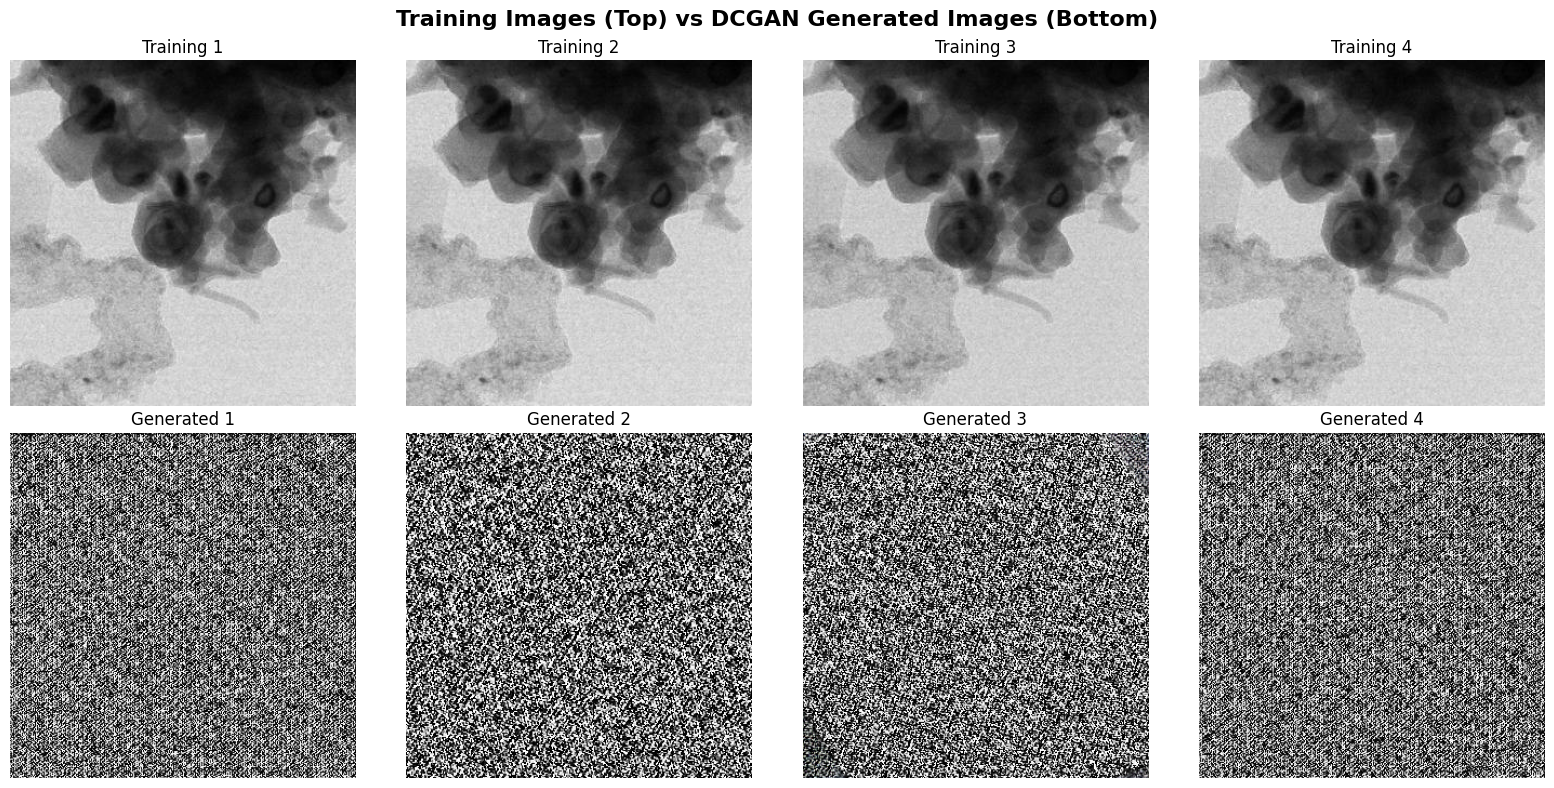

Comparison shows DCGAN learned to generate similar but novel images


In [8]:
# Load preprocessed training images
input_images_dir = prep_manager_dcgan.input_images_preprocessed_dir
input_files = sorted([f for f in os.listdir(input_images_dir) if f.endswith(('.png', '.jpg'))])[:4]

# Create comparison plot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Training Images (Top) vs DCGAN Generated Images (Bottom)', 
             fontsize=16, fontweight='bold')

# Display training images
for idx, img_file in enumerate(input_files):
    img_path = os.path.join(input_images_dir, img_file)
    img = Image.open(img_path)
    axes[0, idx].imshow(img, cmap='gray')
    axes[0, idx].set_title(f'Training {idx+1}')
    axes[0, idx].axis('off')

# Display generated images
for idx, img_file in enumerate(image_files[:4]):
    img_path = os.path.join(output_images_dir, img_file)
    img = Image.open(img_path)
    axes[1, idx].imshow(img, cmap='gray')
    axes[1, idx].set_title(f'Generated {idx+1}')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

print("Comparison shows DCGAN learned to generate similar but novel images")

### Distribution Alignment Between Real and Synthetic Data
By juxtaposing a subset of original training images with DCGAN-generated samples, this cell provides a qualitative check of how well the learned distribution overlaps with the empirical data distribution.
The closer the synthetic images resemble but do not duplicate the training examples, the more confidently we can use the model for data augmentation without severely distorting the underlying electrochemical statistics.

Epochs: 100
Last D acc: 50.28% | slope(last50): -0.0001 per epoch
Last D loss: 3.2376 | slope(last50): 0.0098
Last G loss: 0.0219 | slope(last50): -0.0004


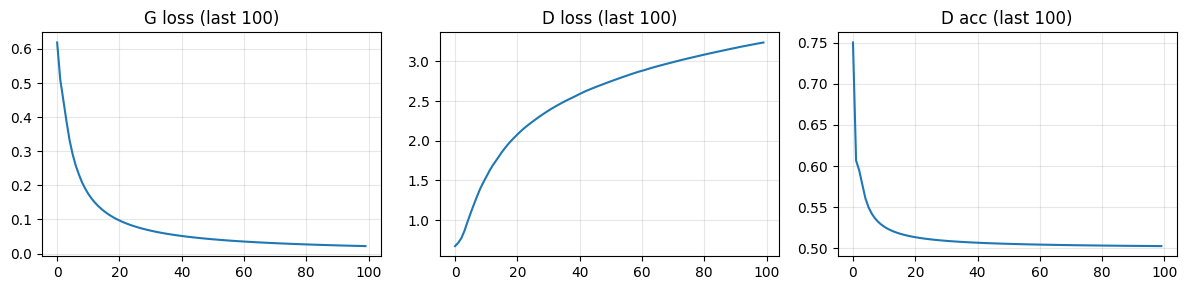

D acc stable; modest gains possible with more epochs.


In [9]:
# Inspect saved training metrics to decide if more epochs help
import os, numpy as np, matplotlib.pyplot as plt

models_dir = prep_manager_dcgan.synth_models_dir
paths = {
    'd_losses': os.path.join(models_dir, 'd_losses.npy'),
    'g_losses': os.path.join(models_dir, 'g_losses.npy'),
    'd_acc': os.path.join(models_dir, 'd_accuracies.npy'),
}

missing = [k for k,p in paths.items() if not os.path.exists(p)]
if missing:
    print(f"Missing histories for: {missing}. Train first to generate curves.")
else:
    d_losses = np.load(paths['d_losses']).astype(float)
    g_losses = np.load(paths['g_losses']).astype(float)
    d_acc = np.load(paths['d_acc']).astype(float)

    n = len(d_losses)
    tail = min(50, n)

    # Simple trend estimate: slope over last K points
    def slope_last_k(arr, k=50):
        k = min(k, len(arr))
        if k < 5:
            return np.nan
        y = arr[-k:]
        x = np.arange(k)
        # Least squares slope
        denom = (k * (k-1) * (2*k-1)) / 6 - ( (k*(k-1)/2)**2 ) / k
        if denom == 0:
            return np.nan
        y_mean = y.mean()
        x_mean = x.mean()
        num = np.sum((x - x_mean) * (y - y_mean))
        den = np.sum((x - x_mean)**2)
        return float(num / den) if den > 0 else np.nan

    d_acc_slope = slope_last_k(d_acc, 50)
    d_loss_slope = slope_last_k(d_losses, 50)
    g_loss_slope = slope_last_k(g_losses, 50)

    print(f"Epochs: {n}")
    print(f"Last D acc: {d_acc[-1]*100:.2f}% | slope(last50): {d_acc_slope:.4f} per epoch")
    print(f"Last D loss: {d_losses[-1]:.4f} | slope(last50): {d_loss_slope:.4f}")
    print(f"Last G loss: {g_losses[-1]:.4f} | slope(last50): {g_loss_slope:.4f}")

    # Plot last 100 epochs for readability
    view = min(100, n)
    fig, ax = plt.subplots(1,3, figsize=(12,3))
    ax[0].plot(np.arange(n-view,n), g_losses[-view:]); ax[0].set_title('G loss (last 100)')
    ax[1].plot(np.arange(n-view,n), d_losses[-view:]); ax[1].set_title('D loss (last 100)')
    ax[2].plot(np.arange(n-view,n), d_acc[-view:]);   ax[2].set_title('D acc (last 100)')
    for a in ax: a.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # Heuristic suggestion
    if np.isnan(d_acc_slope):
        print("Not enough data to assess trend; consider more training.")
    else:
        if d_acc_slope > 0.0005:
            print("D acc trending up; more epochs likely to help.")
        elif d_acc[-1] < 0.25:
            print("D acc very low and not improving; consider reducing LR to 1e-4, batch_size 32 or increasing D capacity.")
        else:
            print("D acc stable; modest gains possible with more epochs.")